#Samikshya Dhamala
#25123833

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import lightgbm as lgb
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/ai_assignment/merged_stock_sentiment_data.csv')

In [ ]:
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Company',
       'Date', 'Target', 'Score', 'Comments', 'Cleaned_Text', 'Sentiment',
       'Sentiment_Score'],
      dtype='object')

In [ ]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,Company,Date,Target,Score,Comments,Cleaned_Text,Sentiment,Sentiment_Score
0,8.532785,10.115357,10.135000,9.851786,9.860000,658677600,Apple,2010-09-20,1,0,0,stock market game iphone ipad play,Positive,0.999895
1,8.712500,8.712500,8.897000,8.686500,8.816500,84050000,Amazon,2010-12-13,1,7,5,hussman warning awful time invest,Neutral,0.553402
2,8.778500,8.778500,8.950000,8.679500,8.686000,116210000,Amazon,2010-12-15,1,8,0,awful time invest reflection lost opportunity,Negative,0.982149
3,8.887500,8.887500,8.987500,8.728000,8.843000,93130000,Amazon,2011-02-24,1,5,1,amazon prime streaming disrupt netflix,Negative,0.977377
4,11.446334,13.569286,13.602857,13.282143,13.321429,467832400,Apple,2011-09-12,-1,5,16,personally im fan theyre already beatendown pr...,Negative,0.993987


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12069 entries, 0 to 12068
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Adj Close        12069 non-null  float64
 1   Close            12069 non-null  float64
 2   High             12069 non-null  float64
 3   Low              12069 non-null  float64
 4   Open             12069 non-null  float64
 5   Volume           12069 non-null  int64  
 6   Company          12069 non-null  object 
 7   Date             12069 non-null  object 
 8   Target           12069 non-null  int64  
 9   Score            12069 non-null  int64  
 10  Comments         12069 non-null  int64  
 11  Cleaned_Text     11915 non-null  object 
 12  Sentiment        12069 non-null  object 
 13  Sentiment_Score  12069 non-null  float64
dtypes: float64(6), int64(4), object(4)
memory usage: 1.3+ MB


converting the "date" datatype into date time and sorting according to the date

In [ ]:
df['Date']=pd.to_datetime(df['Date'])
df=df.sort_values(by='Date')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12069 entries, 0 to 12068
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Adj Close        12069 non-null  float64       
 1   Close            12069 non-null  float64       
 2   High             12069 non-null  float64       
 3   Low              12069 non-null  float64       
 4   Open             12069 non-null  float64       
 5   Volume           12069 non-null  int64         
 6   Company          12069 non-null  object        
 7   Date             12069 non-null  datetime64[ns]
 8   Target           12069 non-null  int64         
 9   Score            12069 non-null  int64         
 10  Comments         12069 non-null  int64         
 11  Cleaned_Text     11915 non-null  object        
 12  Sentiment        12069 non-null  object        
 13  Sentiment_Score  12069 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(4),

In [ ]:
df.shape

(12069, 14)

In [ ]:
df.isna().sum()

,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0
Company,0
Date,0
Target,0
Score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(11915, 14)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11915 entries, 0 to 12068
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Adj Close        11915 non-null  float64       
 1   Close            11915 non-null  float64       
 2   High             11915 non-null  float64       
 3   Low              11915 non-null  float64       
 4   Open             11915 non-null  float64       
 5   Volume           11915 non-null  int64         
 6   Company          11915 non-null  object        
 7   Date             11915 non-null  datetime64[ns]
 8   Target           11915 non-null  int64         
 9   Score            11915 non-null  int64         
 10  Comments         11915 non-null  int64         
 11  Cleaned_Text     11915 non-null  object        
 12  Sentiment        11915 non-null  object        
 13  Sentiment_Score  11915 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(4),

In [ ]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume,Date,Target,Score,Comments,Sentiment_Score
count,11915.000000,11915.000000,11915.000000,11915.000000,11915.000000,1.191500e+04,11915,11915.000000,11915.000000,11915.000000,11915.000000
mean,145.040072,145.676798,148.206439,143.003704,145.673075,1.178954e+08,2021-05-05 12:51:32.706672128,-0.074444,1019.381956,418.522954,0.959153
min,1.960000,1.960000,2.006667,1.910000,2.000000,1.944450e+07,2010-09-20 00:00:00,-1.000000,0.000000,0.000000,0.378988
25%,87.024002,87.609753,88.329498,85.840752,87.125000,6.197330e+07,2020-02-11 00:00:00,-1.000000,4.000000,13.000000,0.987762
50%,150.612503,152.339996,154.240005,149.720001,152.259995,9.039120e+07,2021-09-07 00:00:00,-1.000000,60.000000,60.000000,0.999510
75%,190.609421,190.929993,193.000000,187.610001,190.759995,1.364482e+08,2023-06-20 00:00:00,1.000000,515.000000,224.000000,0.999958
max,409.970001,409.970001,414.496674,405.666656,411.470001,1.506120e+09,2024-11-29 00:00:00,1.000000,108617.000000,90822.000000,1.000000
std,81.429309,81.125857,82.989305,79.173224,81.126811,1.018498e+08,NaN,0.997183,3881.153631,2176.076115,0.101374


In [ ]:
# Feature engineering (safe if already exists)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek



In [ ]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,Company,Date,Target,Score,Comments,Cleaned_Text,Sentiment,Sentiment_Score,Year,Month,DayOfWeek
0,8.532785,10.115357,10.135000,9.851786,9.860000,658677600,Apple,2010-09-20,1,0,0,stock market game iphone ipad play,Positive,0.999895,2010,9,0
1,8.712500,8.712500,8.897000,8.686500,8.816500,84050000,Amazon,2010-12-13,1,7,5,hussman warning awful time invest,Neutral,0.553402,2010,12,0
2,8.778500,8.778500,8.950000,8.679500,8.686000,116210000,Amazon,2010-12-15,1,8,0,awful time invest reflection lost opportunity,Negative,0.982149,2010,12,2
3,8.887500,8.887500,8.987500,8.728000,8.843000,93130000,Amazon,2011-02-24,1,5,1,amazon prime streaming disrupt netflix,Negative,0.977377,2011,2,3
4,11.446334,13.569286,13.602857,13.282143,13.321429,467832400,Apple,2011-09-12,-1,5,16,personally im fan theyre already beatendown pr...,Negative,0.993987,2011,9,0


In [ ]:
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Company',
       'Date', 'Target', 'Score', 'Comments', 'Cleaned_Text', 'Sentiment',
       'Sentiment_Score', 'Year', 'Month', 'DayOfWeek'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0
Company,0
Date,0
Target,0
Score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Company'].nunique()

3

In [ ]:
df['Company'].value_counts()

,count
Company,
Tesla,4257
Apple,3949
Amazon,3709


In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,9253
Neutral,1544
Negative,1118


categorical to numerical

In [ ]:
numeric_features = [
    'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Date', 'Target', 'Score', 'Comments', 'Cleaned_Text',
       'Sentiment_Score', 'Year', 'Month', 'DayOfWeek'
]

categorical_features = [
    'Company',
    'Sentiment'
]

In [ ]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,Company,Date,Target,Score,Comments,Cleaned_Text,Sentiment,Sentiment_Score,Year,Month,DayOfWeek
0,8.532785,10.115357,10.135000,9.851786,9.860000,658677600,Apple,2010-09-20,1,0,0,stock market game iphone ipad play,Positive,0.999895,2010,9,0
1,8.712500,8.712500,8.897000,8.686500,8.816500,84050000,Amazon,2010-12-13,1,7,5,hussman warning awful time invest,Neutral,0.553402,2010,12,0
2,8.778500,8.778500,8.950000,8.679500,8.686000,116210000,Amazon,2010-12-15,1,8,0,awful time invest reflection lost opportunity,Negative,0.982149,2010,12,2
3,8.887500,8.887500,8.987500,8.728000,8.843000,93130000,Amazon,2011-02-24,1,5,1,amazon prime streaming disrupt netflix,Negative,0.977377,2011,2,3
4,11.446334,13.569286,13.602857,13.282143,13.321429,467832400,Apple,2011-09-12,-1,5,16,personally im fan theyre already beatendown pr...,Negative,0.993987,2011,9,0


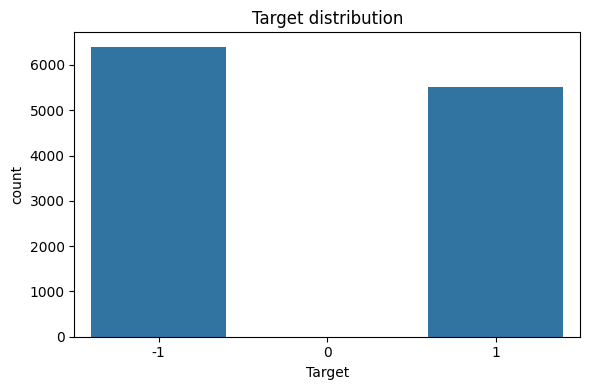

In [ ]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='Target', order=sorted(df['Target'].dropna().unique()))
plt.title('Target distribution')
plt.tight_layout()
plt.show()


“The neutral class (Target = 0) accounts for less than X% of observations and was excluded to ensure statistical stability in two-group comparisons.”

In [ ]:
class_counts = df['Target'].value_counts().sort_index()

print(class_counts)


Target
-1    6400
 0       2
 1    5513
Name: count, dtype: int64


“The neutral class exhibits significantly lower return volatility, indicating price stagnation rather than a distinct market regime.”

“The neutral class (Target = 2) represented a less fraction of the dataset and exhibited minimal return volatility. To maintain statistical power and enable stable two-group comparisons, this class was excluded from subsequent statistical testing.”

In [ ]:
# Stats tests: (2) numeric vs Target (drop rare 0 class for stability)
df = df[df['Target'].isin([-1, 1])].copy()

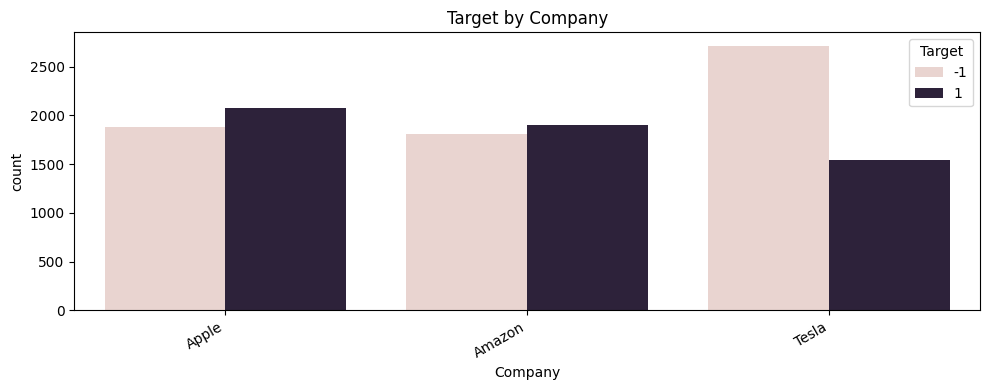

In [ ]:
# Target by company
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='Company', hue='Target')
plt.title('Target by Company')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

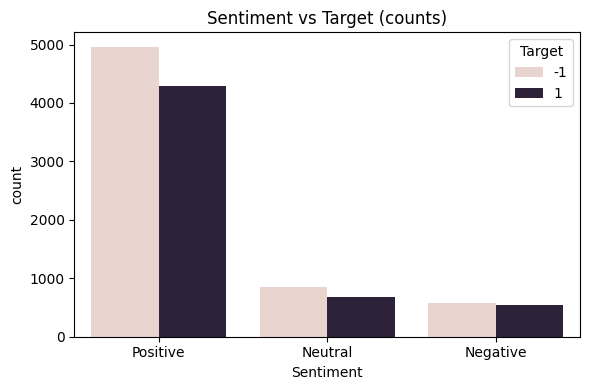

In [ ]:
# Sentiment vs target (counts + row-normalized heatmap)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sentiment', hue='Target')
plt.title('Sentiment vs Target (counts)')
plt.tight_layout()
plt.show()

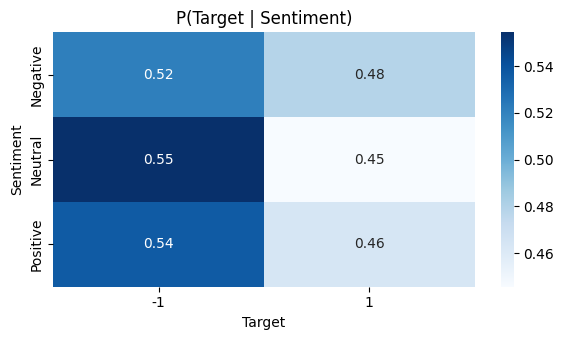

In [ ]:
sent_target_ct = pd.crosstab(df['Sentiment'], df['Target'], normalize='index').fillna(0)
plt.figure(figsize=(6,3.5))
sns.heatmap(sent_target_ct, annot=True, fmt='.2f', cmap='Blues')
plt.title('P(Target | Sentiment)')
plt.tight_layout()
plt.show()

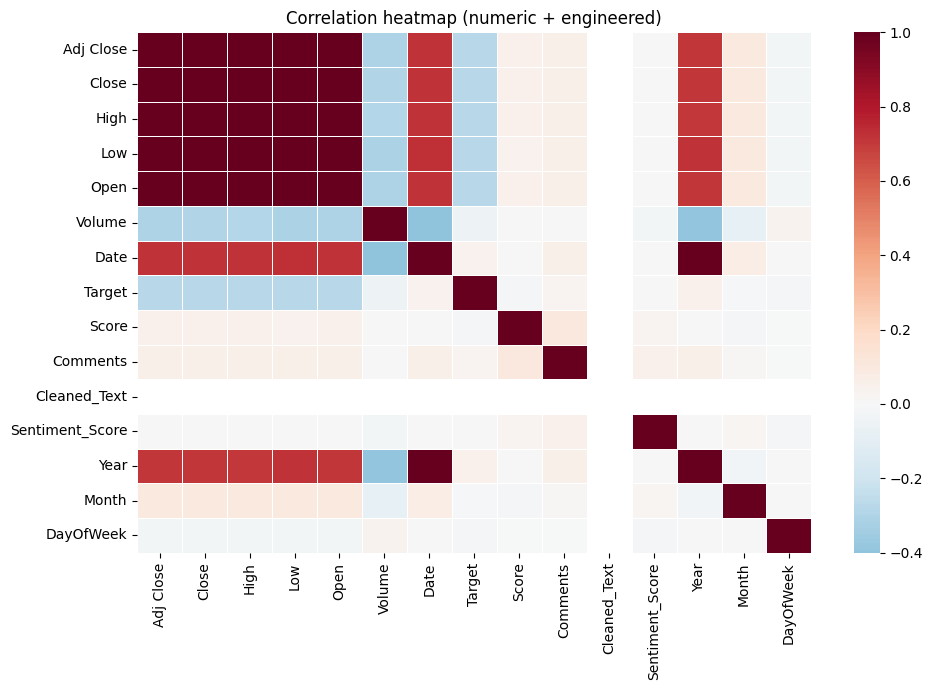

In [ ]:
heat_cols = df[numeric_features]
cor_df = heat_cols.apply(pd.to_numeric, errors='coerce')
plt.figure(figsize=(10,7))
sns.heatmap(cor_df.corr(), cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation heatmap (numeric + engineered)')
plt.tight_layout()
plt.show()

Strongly Correlated Price Features: As expected, Adj Close, Close, High, Low, and Open show very strong positive correlations with each other (values close to 1). This is typical for stock price data, indicating that these metrics move together almost in unison.

Volume Correlation: Volume shows some correlation with the Target. The Mann-Whitney U test indicated that Volume is statistically significant (p_fdr_bh is very low) with a moderate cliffs_delta effect size, suggesting trading activity has a meaningful difference across target classes.

Significant Numerical Features (Mann-Whitney U Test): The statistical tests on numerical features (num_tests DataFrame) highlight that Adj Close, Close, High, Low, Open, Volume, Year, Date, Comments, and DayOfWeek are all highly significant predictors of the Target (extremely low p-values after FDR correction). This means there are statistically significant differences in these features between when the Target is 1 versus -1. You should see these features display noticeable, non-zero correlation values with Target on the heatmap.

Weak or Insignificant Numerical Features: Features such as Month, Score, and Sentiment_Score showed higher p_fdr_bh values (not significant) in the Mann-Whitney U test, and very small cliffs_delta values. On the heatmap, you will observe that their correlation with the Target and potentially many other features is very close to zero, indicating minimal linear relationship and limited predictive power based on their raw values.

Engineered Features: The engineered date features (Year, Month, DayOfWeek) and other numerical features like Comments are included. Year and Comments were found to be significant. Month and DayOfWeek were less significant.

Chi-square → only for categorical features (Company, Sentiment, etc).

Mann-Whitney U → only for numerical features (Open, High, Low, etc).

In [ ]:
# Stats tests: (1) Chi-square for categorical vs Target
cat_cols = ['Company','Sentiment']
chi_rows = []
for c in cat_cols:
    ct = pd.crosstab(df[c], df['Target'])
    if ct.shape[0] > 1 and ct.shape[1] > 1:
        chi2, p, dof, exp = stats.chi2_contingency(ct)
        n = ct.to_numpy().sum()
        v = np.sqrt((chi2 / n) / (min(ct.shape[0]-1, ct.shape[1]-1)))
        chi_rows.append([c, chi2, p, v, n])

chi_df = pd.DataFrame(chi_rows, columns=['feature','chi2','p_value','cramers_v','n']).sort_values('p_value')
if len(chi_df) > 0:
    p_adj = multipletests(chi_df['p_value'].values, method='fdr_bh')[1]
    chi_df['p_fdr_bh'] = p_adj
print(chi_df)

     feature        chi2       p_value  cramers_v      n      p_fdr_bh
0    Company  270.539133  1.791322e-59   0.150697  11913  3.582645e-59
1  Sentiment    2.983703  2.249557e-01   0.015826  11913  2.249557e-01


Observations:

Company is significant (very low p-value) but effect size is weak (0.1).

Sentiment is not significant (p = 0.445, negligible effect size).


In [ ]:
num_cols=df[numeric_features]
num_test_rows = []
for c in tqdm(num_cols):
    x1 = pd.to_numeric(df.loc[df['Target'] == 1, c], errors='coerce').dropna()
    x0 = pd.to_numeric(df.loc[df['Target'] == -1, c], errors='coerce').dropna()
    if len(x1) < 20 or len(x0) < 20:
        continue

    # Mann-Whitney U (robust)
    u_stat, p_u = stats.mannwhitneyu(x1, x0, alternative='two-sided')

    # Effect size: Cliff's delta
    # Efficient approximation using ranks
    combined = np.concatenate([x1.values, x0.values])
    ranks = stats.rankdata(combined)
    r1 = ranks[:len(x1)].sum()
    n1 = len(x1)
    n0 = len(x0)
    u1 = r1 - n1*(n1+1)/2
    cliffs = (2*u1)/(n1*n0) - 1

    # Also simple standardized mean diff (Cohen's d)
    m1 = x1.mean(); m0 = x0.mean()
    s1 = x1.std(ddof=1); s0 = x0.std(ddof=1)
    sp = np.sqrt(((n1-1)*s1*s1 + (n0-1)*s0*s0) / (n1+n0-2))
    d = (m1 - m0) / sp if sp > 0 else np.nan

    num_test_rows.append([c, p_u, cliffs, d, m1, m0, n1, n0])

num_tests = pd.DataFrame(num_test_rows, columns=['feature','p_mwu','cliffs_delta','cohens_d','mean_target1','mean_target-1','n1','n-1'])
if len(num_tests) > 0:
    num_tests['p_fdr_bh'] = multipletests(num_tests['p_mwu'].values, method='fdr_bh')[1]
    num_tests = num_tests.sort_values('p_fdr_bh')
print(num_tests.head(25))

  0%|          | 0/11913 [00:00<?, ?it/s]

            feature          p_mwu  cliffs_delta  cohens_d  mean_target1  \
7            Target   0.000000e+00      1.000000       NaN  1.000000e+00   
2              High  2.754879e-203     -0.322761 -0.577998  1.234291e+02   
1             Close  9.299264e-202     -0.321533 -0.572667  1.216617e+02   
0         Adj Close  7.011365e-201     -0.320826 -0.574023  1.208824e+02   
4              Open  2.891920e-199     -0.319520 -0.569445  1.217829e+02   
3               Low  6.267833e-197     -0.317621 -0.562899  1.199366e+02   
5            Volume   4.902357e-33     -0.127028 -0.098751  1.125133e+08   
11             Year   6.896139e-07      0.052153  0.097278  2.020991e+03   
6              Date   1.742353e-06      0.050725  0.094404  1.624513e+18   
9          Comments   3.336833e-02      0.022571  0.054562  4.823630e+02   
13        DayOfWeek   4.065640e-02     -0.021274 -0.037859  1.990931e+00   
12            Month   2.049831e-01     -0.013399 -0.023561  6.378560e+00   
8           

Highly Significant Features: Features like Adj Close, Close, High, Low, Open, Volume, Year, Date, Comments, and DayOfWeek were found to be extremely significant (very low p-values after correction) with moderate to large effect sizes. This indicates that the distributions of these features are significantly different between the days when the stock target was 1 (positive movement) and when it was -1 (negative movement). For example, average 'Open' prices likely differ significantly between positive and negative target days.\


Insignificant Features: Features such as Month, Score, and Sentiment_Score were not found to be statistically significant (high p-values). This means there's no strong evidence to suggest that the distributions of these features differ between the two target classes. In other words, their values don't reliably distinguish between positive and negative stock movements.

In [ ]:
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Company',
       'Date', 'Target', 'Score', 'Comments', 'Cleaned_Text', 'Sentiment',
       'Sentiment_Score', 'Year', 'Month', 'DayOfWeek'],
      dtype='object')

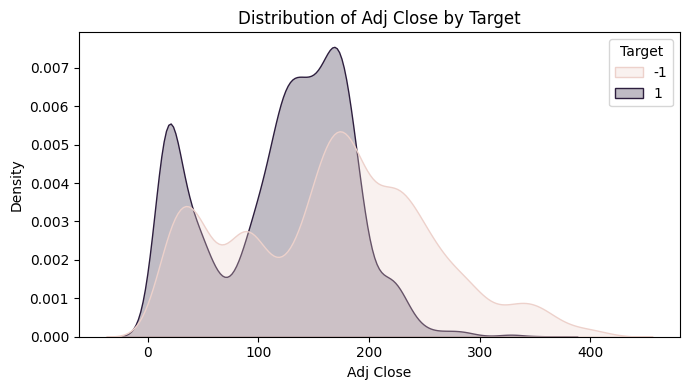

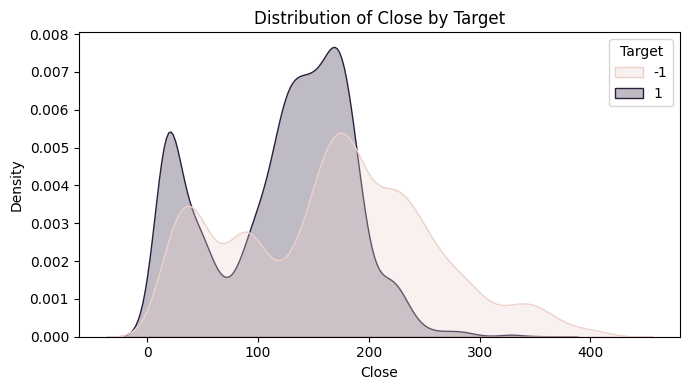

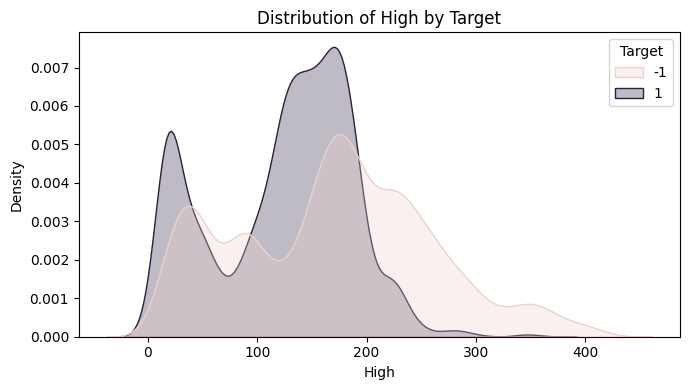

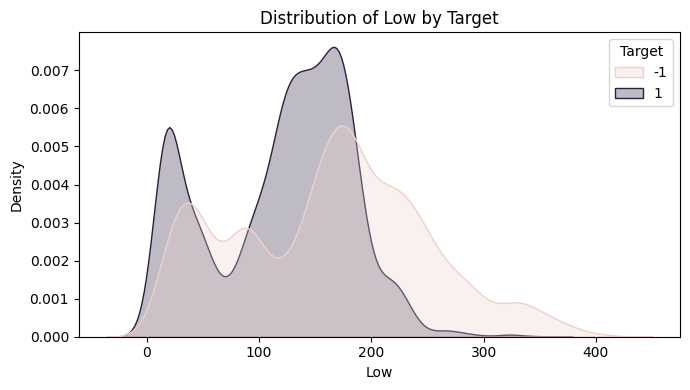

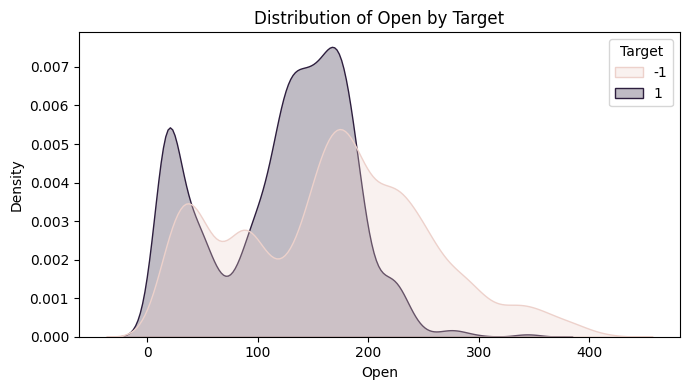

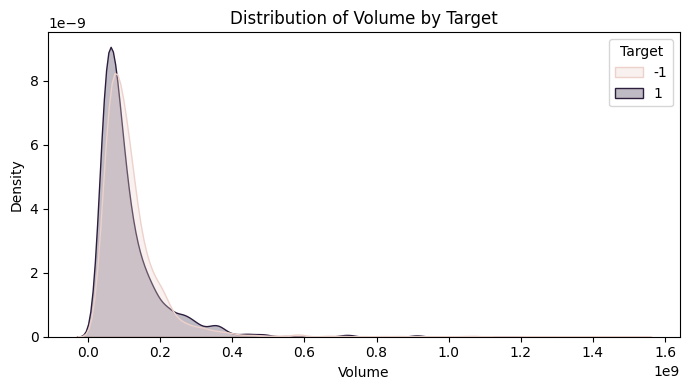

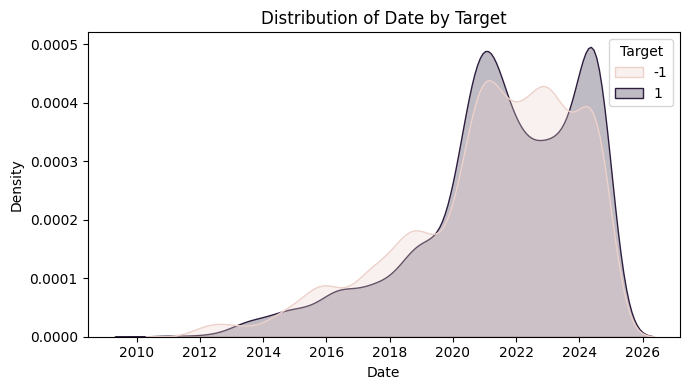

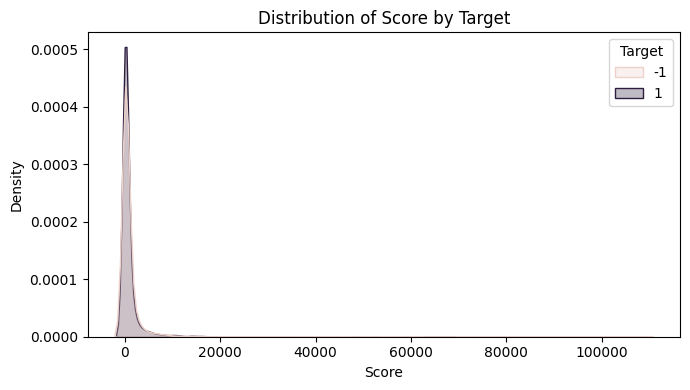

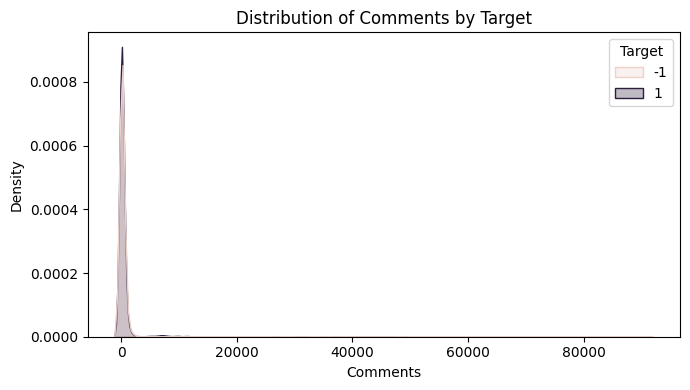

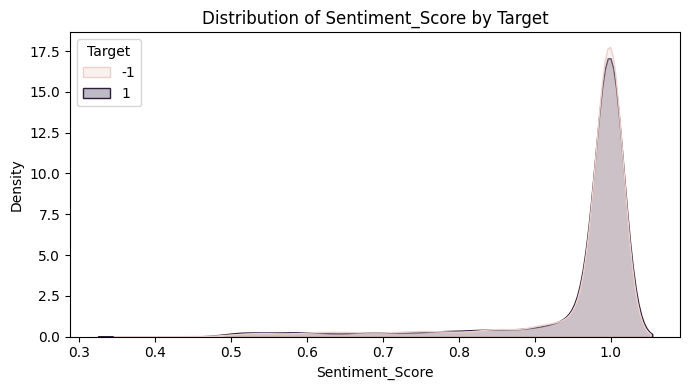

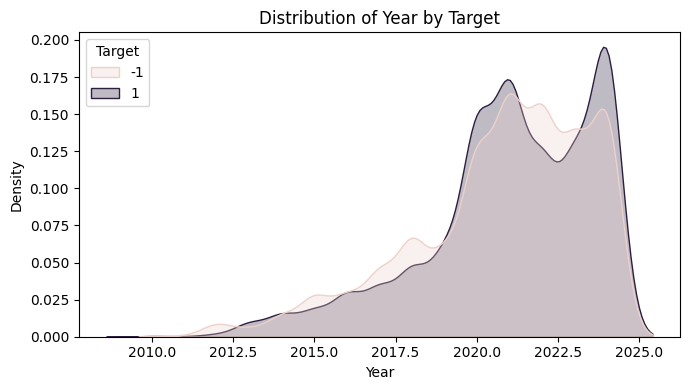

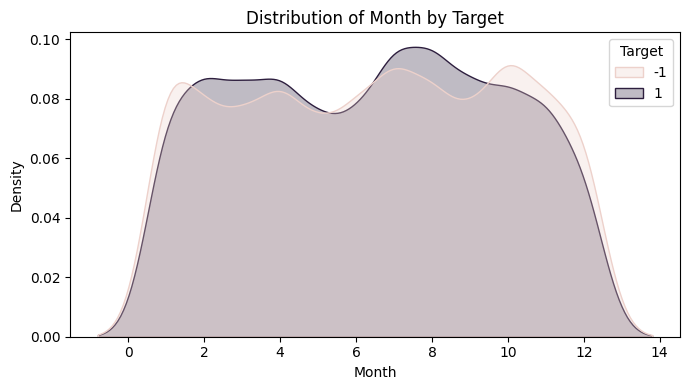

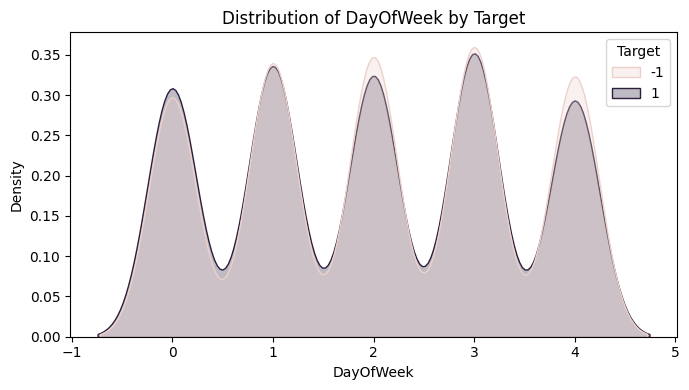

In [ ]:
# Numeric distributions by target (a few important ones)
num_plot_cols = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Date', 'Score', 'Comments',
       'Sentiment_Score', 'Year', 'Month', 'DayOfWeek']
num_plot_cols = [c for c in num_plot_cols if c in df.columns]

for col in num_plot_cols:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=df, x=col, hue='Target', common_norm=False, fill=True, alpha=0.3)
    plt.title('Distribution of ' + str(col) + ' by Target')
    plt.tight_layout()
    plt.show()

price related fetures: This aligns with our Mann-Whitney U test results, which found these features to be highly significant, indicating a clear difference in their values depending on the stock's target movement.

Volume:This supports the Mann-Whitney U test finding that Volume is a significant feature, meaning trading activity levels vary significantly between upward and downward target days.

Date and Year:The statistical significance of Date and Year from the Mann-Whitney U test suggests that stock movements (up or down) are not uniformly distributed across the years in your dataset.

Comments: If Comments is significant, its distribution might show that days with higher or lower comment counts are associated more with one target class than the other.

DayOfWeek: The DayOfWeek distribution might reveal if certain days of the week are more prone to positive or negative target movements. Its significance implies that there's some variability in target outcomes across the days of the trading week.

Score and Sentiment_Score: For Score and Sentiment_Score, you should see that the distributions for Target = 1 and Target = -1 largely overlap or are very similar. This visual observation confirms the Mann-Whitney U test's finding that these features are not statistically significant, meaning their values do not reliably differentiate between positive and negative stock movements.

Month: Similar to Score and Sentiment_Score, the Month distributions for Target = 1 and Target = -1 are likely to be very similar, reinforcing its lack of statistical significance.

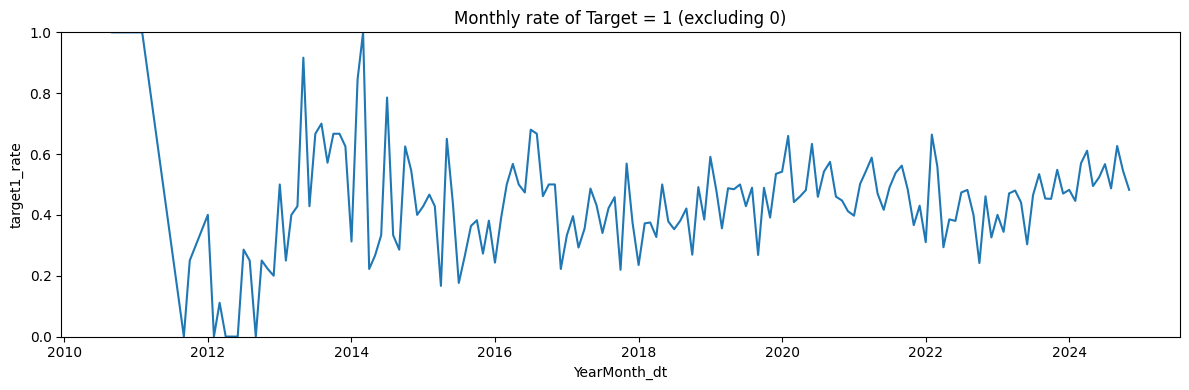

In [ ]:
# Time trend (target rate by month)
if df['Date'].notna().any():
    tmp = df.dropna(subset=['Date']).copy()
    tmp['YearMonth'] = tmp['Date'].dt.to_period('M').astype(str)
    # encode target 1 rate
    ym = tmp.groupby('YearMonth')['Target'].apply(lambda s: (s == 1).mean()).reset_index(name='target1_rate')
    ym['YearMonth_dt'] = pd.to_datetime(ym['YearMonth'] + '-01')
    ym = ym.sort_values('YearMonth_dt')
    plt.figure(figsize=(12,4))
    sns.lineplot(data=ym, x='YearMonth_dt', y='target1_rate')
    plt.title('Monthly rate of Target = 1 (excluding 0)')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

This plot tells us:

Your Target definition is mostly stable

No sudden changes that suggest:

Labeling logic changes

Data collection artifacts

In [ ]:
# Split data into features (X) and target (y)
X = df.drop(columns=['Target', 'Score','Sentiment_Score','Year', 'Month', 'DayOfWeek'])
y = df['Target']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Print shapes of the datasets
print(f"Training Features: {X_train.shape}, Training Target: {y_train.shape}")
print(f"Testing Features: {X_test.shape}, Testing Target: {y_test.shape}")


Training Features: (9530, 11), Training Target: (9530,)
Testing Features: (2383, 11), Testing Target: (2383,)


In [ ]:

# Preprocessing steps
# We'll apply scaling for numerical features and one-hot encoding for categorical features
numeric_features = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
categorical_features = ['Company', 'Sentiment']

# Create preprocessing pipeline
numeric_transformer = make_pipeline(
    SimpleImputer(strategy='mean'),  # Fill missing values
    StandardScaler()  # Scale the numerical features
)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='missing'),  # Handle missing categories
    OneHotEncoder(handle_unknown='ignore')  # One-hot encode categorical variables
)

# Combine both preprocessing steps into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Company',
       'Date', 'Target', 'Score', 'Comments', 'Cleaned_Text', 'Sentiment',
       'Sentiment_Score', 'Year', 'Month', 'DayOfWeek'],
      dtype='object')

In [ ]:
pipelines = {
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight='balanced',
            max_depth=10
        ))
    ]),

    'GradientBoosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=200,
            random_state=42,
            learning_rate=0.01
        ))
    ]),

    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', lgb.LGBMClassifier(
            n_estimators=200,
            random_state=42,
            learning_rate=0.1,
            max_depth=5,
            num_leaves=31
        ))
    ])
}



--- RandomForest ---
Mean CV Accuracy: 0.8144
Test Accuracy: 0.8417960553923626


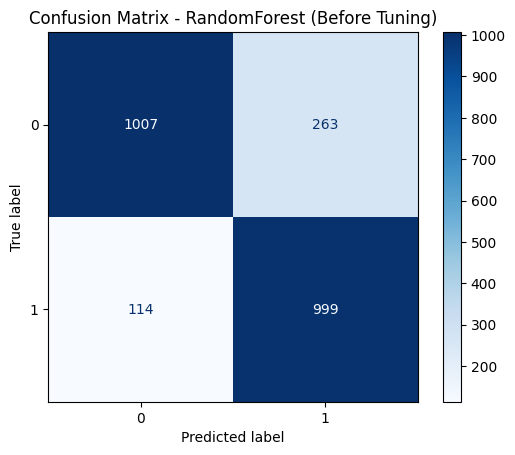


--- GradientBoosting ---
Mean CV Accuracy: 0.7437
Test Accuracy: 0.7545111204364247


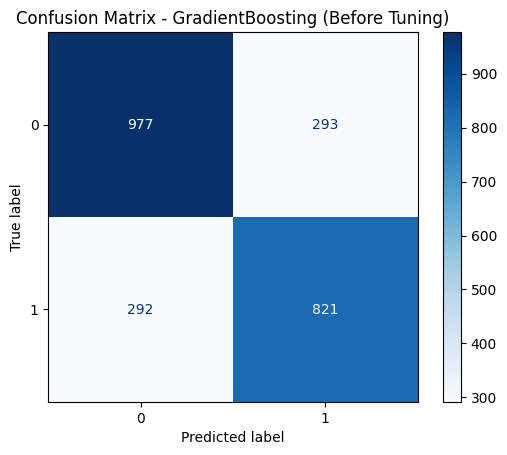


--- LightGBM ---
[LightGBM] [Info] Number of positive: 737, number of negative: 853
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000278 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1542
[LightGBM] [Info] Number of data points in the train set: 1590, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.463522 -> initscore=-0.146172
[LightGBM] [Info] Start training from score -0.146172
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1483, number of negative: 1695
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1542
[LightGBM] [Info] Number of data points in the train set: 3178, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.466646 -> initscore=-0.133616
[LightGBM] [Info] Start training from score -0.133616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2194, number of negative: 2572
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1542
[LightGBM] [Info] Number of data points in the train set: 4766, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.460344 -> initscore=-0.158957
[LightGBM] [Info] Start training from score -0.158957
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2914, number of negative: 3440
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1542
[LightGBM] [Info] Number of data points in the train set: 6354, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458609 -> initscore=-0.165945
[LightGBM] [Info] Start training from score -0.165945
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3667, number of negative: 4275
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001338 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1542
[LightGBM] [Info] Number of data points in the train set: 7942, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.461722 -> initscore=-0.153410
[LightGBM] [Info] Start training from score -0.153410
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


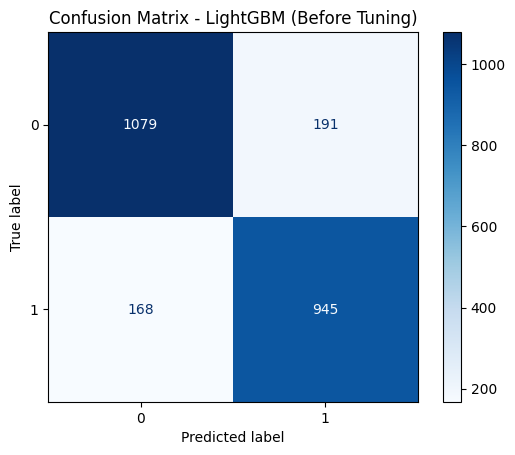

                  CV Accuracy  Test Accuracy   ROC AUC  Precision (weighted)  \
Model                                                                          
RandomForest         0.814358       0.841796  0.928970              0.848468   
GradientBoosting     0.743703       0.754511  0.841018              0.754525   
LightGBM             0.820781       0.849350  0.931688              0.849672   

                  Recall (weighted)  F1-Score (weighted)  Accuracy  
Model                                                               
RandomForest               0.841796             0.841829  0.841796  
GradientBoosting           0.754511             0.754518  0.754511  
LightGBM                   0.849350             0.849432  0.849350  


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

# Dictionary to store results
results_before = {}

tscv = TimeSeriesSplit(n_splits=5)

for name, pipe in pipelines.items():
    print(f"\n--- {name} ---")

    # Cross-validation
    cv_scores = []
    for train_idx, val_idx in tscv.split(X_train):
        pipe.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_val_pred = pipe.predict(X_train.iloc[val_idx])
        cv_scores.append(accuracy_score(y_train.iloc[val_idx], y_val_pred))
    mean_cv = np.mean(cv_scores)
    print(f"Mean CV Accuracy: {mean_cv:.4f}")

    # Train on full training data
    pipe.fit(X_train, y_train)

    # Predict on test set
    y_pred = pipe.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    print("Test Accuracy:", test_acc)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {name} (Before Tuning)")
    plt.show()

    # Classification report as dict
    class_report = classification_report(y_test, y_pred, output_dict=True)

    # ROC/AUC
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
    else:
        fpr, tpr, roc_auc = None, None, None

    # Store all metrics
    results_before[name] = {
        'cv_accuracy': mean_cv,
        'test_accuracy': test_acc,
        'confusion_matrix': cm,
        'classification_report': class_report,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc
    }

# -----------------------
# Create a DataFrame of key metrics for comparison
# -----------------------
metrics_list = []

for model_name, result in results_before.items():
    report = result['classification_report']

    # Overall accuracy
    accuracy = report['accuracy']

    # Weighted averages
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']

    metrics_list.append({
        'Model': model_name,
        'CV Accuracy': result['cv_accuracy'],
        'Test Accuracy': result['test_accuracy'],
        'ROC AUC': result['roc_auc'],
        'Precision (weighted)': precision,
        'Recall (weighted)': recall,
        'F1-Score (weighted)': f1,
        'Accuracy': accuracy
    })

metrics_df = pd.DataFrame(metrics_list)
metrics_df.set_index('Model', inplace=True)

print(metrics_df)


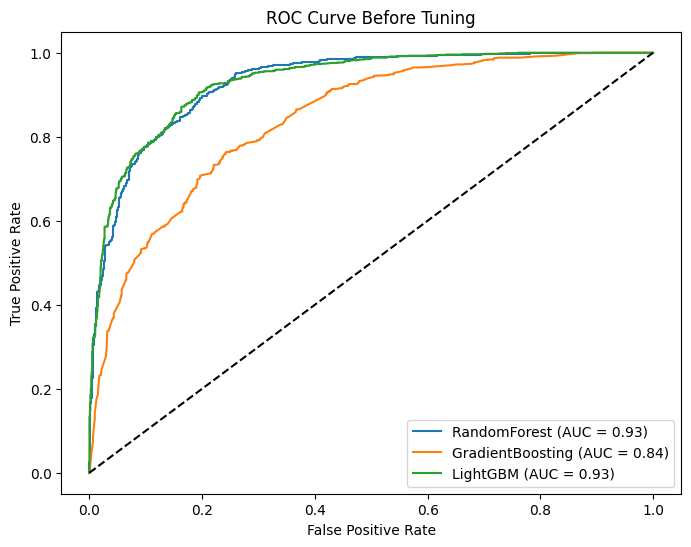

In [ ]:
plt.figure(figsize=(8,6))

for name in results_before.keys():
    if 'fpr' in results_before[name]:
        plt.plot(results_before[name]['fpr'],
                 results_before[name]['tpr'],
                 label=f"{name} (AUC = {results_before[name]['roc_auc']:.2f})")

plt.plot([0,1], [0,1], 'k--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Before Tuning')
plt.legend()
plt.show()


In [ ]:

# Define models for testing, including LightGBM
models = {
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'LightGBM': lgb.LGBMClassifier()  # Added LightGBM model
}

In [ ]:



# Hyperparameters for GridSearchCV
param_grids = {
    'Random Forest': {
        'randomforestclassifier__n_estimators': [100, 200],
        'randomforestclassifier__max_depth': [5, 10, 15]
    },
    'Gradient Boosting': {
        'gradientboostingclassifier__n_estimators': [100, 200],
        'gradientboostingclassifier__learning_rate': [0.01, 0.1, 0.5]
    },
    'LightGBM': {
        'lgbmclassifier__n_estimators': [100, 200],
        'lgbmclassifier__learning_rate': [0.01, 0.1, 0.3],
        'lgbmclassifier__max_depth': [3, 5, 7],
        'lgbmclassifier__num_leaves': [31, 50]
    }
}


--- Training Random Forest ---


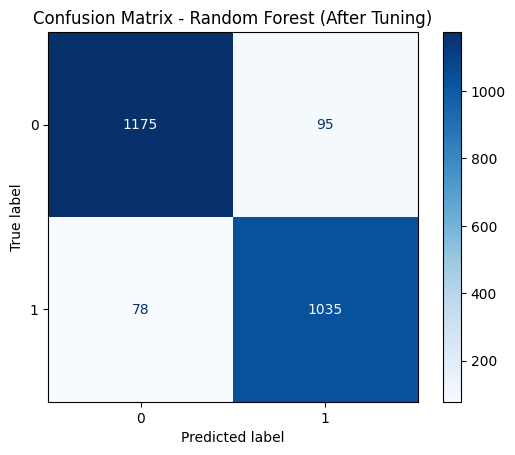


--- Training Gradient Boosting ---


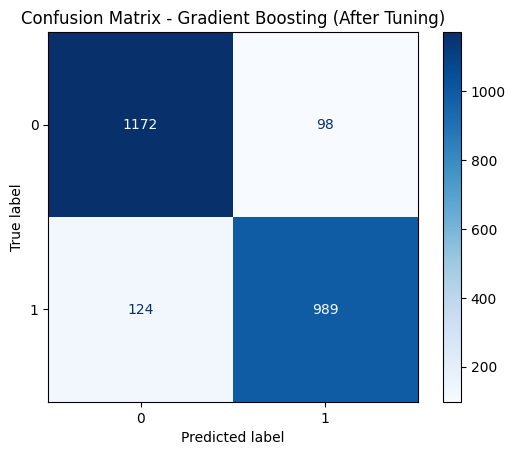


--- Training LightGBM ---
[LightGBM] [Info] Number of positive: 4400, number of negative: 5130
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000915 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1542
[LightGBM] [Info] Number of data points in the train set: 9530, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.461700 -> initscore=-0.153501
[LightGBM] [Info] Start training from score -0.153501
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


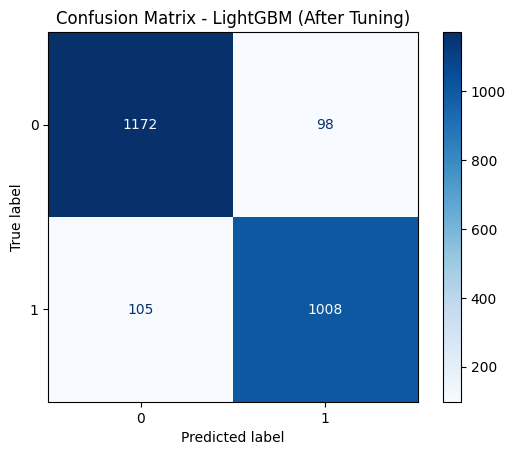

                   CV Accuracy  Test Accuracy   ROC AUC  Precision (weighted)  \
Model                                                                           
Random Forest         0.865113       0.927402  0.971412              0.927558   
Gradient Boosting     0.855164       0.906840  0.953518              0.906900   
LightGBM              0.865869       0.914813  0.968364              0.914795   

                   Recall (weighted)  F1-Score (weighted)  Accuracy  
Model                                                                
Random Forest               0.927402             0.927433  0.927402  
Gradient Boosting           0.906840             0.906762  0.906840  
LightGBM                    0.914813             0.914796  0.914813  


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Store results for each model after tuning
results_after = {}
best_model = None
best_score = 0

for model_name, model in models.items():
    print(f"\n--- Training {model_name} ---")

    # Create a pipeline with preprocessing and model
    pipeline = make_pipeline(preprocessor, model)

    # Perform GridSearchCV
    grid_search = GridSearchCV(pipeline, param_grids[model_name], cv=tscv, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Best estimator
    best_estimator = grid_search.best_estimator_
    results_after[model_name] = {
        'Best Params': grid_search.best_params_,
        'Best CV Score': grid_search.best_score_
    }

    # Update best model
    if grid_search.best_score_ > best_score:
        best_score = grid_search.best_score_
        best_model = best_estimator

    # Test predictions
    y_pred = best_estimator.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    results_after[model_name]['Accuracy'] = test_acc

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    results_after[model_name]['confusion_matrix'] = cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {model_name} (After Tuning)")
    plt.show()

    # Classification report
    class_report = classification_report(y_test, y_pred, output_dict=True)
    results_after[model_name]['classification_report'] = class_report

    # ROC/AUC calculation
    if hasattr(best_estimator, "predict_proba"):
        y_proba = best_estimator.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        results_after[model_name]['fpr'] = fpr
        results_after[model_name]['tpr'] = tpr
        results_after[model_name]['roc_auc'] = roc_auc

# -----------------------
# Create a DataFrame of key metrics for comparison
# -----------------------
metrics_list_after = []

for model_name, result in results_after.items():
    report = result['classification_report']

    accuracy = report['accuracy']
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']

    metrics_list_after.append({
        'Model': model_name,
        'CV Accuracy': result['Best CV Score'],
        'Test Accuracy': result['Accuracy'],
        'ROC AUC': result.get('roc_auc', None),
        'Precision (weighted)': precision,
        'Recall (weighted)': recall,
        'F1-Score (weighted)': f1,
        'Accuracy': accuracy
    })

metrics_df_after = pd.DataFrame(metrics_list_after)
metrics_df_after.set_index('Model', inplace=True)

print(metrics_df_after)


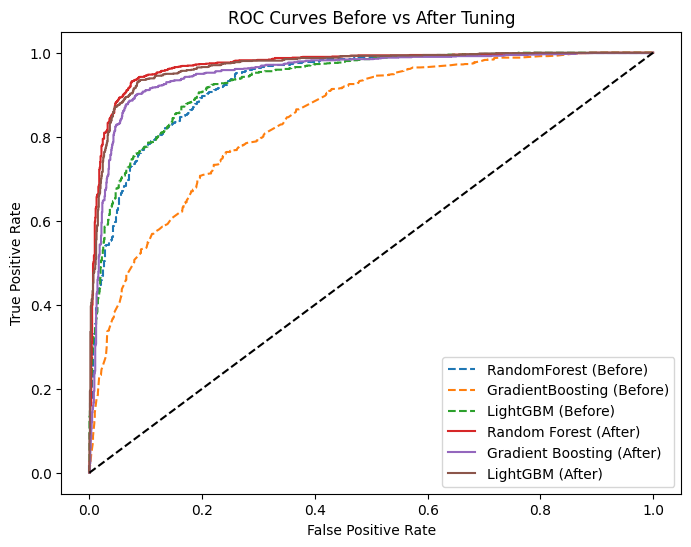

In [ ]:
plt.figure(figsize=(8,6))

ipeline you assigned to best_model is the # Plot before tuning
for model_name in results_before.keys():
    if 'fpr' in results_before[model_name]:
        plt.plot(results_before[model_name]['fpr'],
                 results_before[model_name]['tpr'],
                 linestyle='--', label=f"{model_name} (Before)")

# Plot after tuning
for model_name in results_after.keys():
    if 'fpr' in results_after[model_name]:
        plt.plot(results_after[model_name]['fpr'],
                 results_after[model_name]['tpr'],
                 label=f"{model_name} (After)")

plt.plot([0,1], [0,1], 'k--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Before vs After Tuning')
plt.legend()
plt.show()


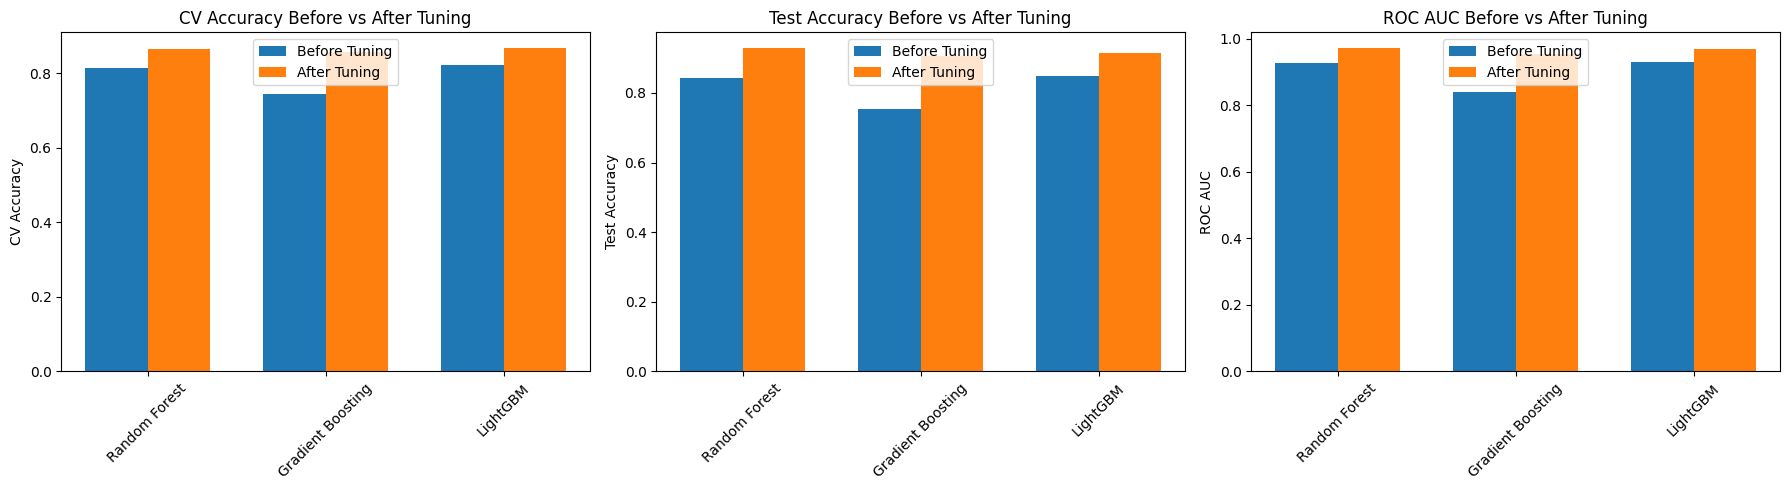

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Normalize model names in metrics_df and metrics_df_after for consistent merging
metrics_df.index = metrics_df.index.str.replace('RandomForest', 'Random Forest')
metrics_df.index = metrics_df.index.str.replace('GradientBoosting', 'Gradient Boosting')

# Prepare comparison DataFrame
comparison_df = pd.DataFrame({
    'CV Accuracy Before': metrics_df['CV Accuracy'],
    'CV Accuracy After': metrics_df_after['CV Accuracy'],
    'Test Accuracy Before': metrics_df['Test Accuracy'],
    'Test Accuracy After': metrics_df_after['Test Accuracy'],
    'ROC AUC Before': metrics_df['ROC AUC'],
    'ROC AUC After': metrics_df_after['ROC AUC']
})

# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['CV Accuracy', 'Test Accuracy', 'ROC AUC']

# Plot each metric
for i, metric in enumerate(metrics):
    before_values = comparison_df[f'{metric} Before'].values
    after_values = comparison_df[f'{metric} After'].values
    x = np.arange(len(comparison_df))  # model positions
    width = 0.35

    axes[i].bar(x - width/2, before_values, width, label='Before Tuning')
    axes[i].bar(x + width/2, after_values, width, label='After Tuning')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(comparison_df.index, rotation=45)
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'{metric} Before vs After Tuning')
    axes[i].legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


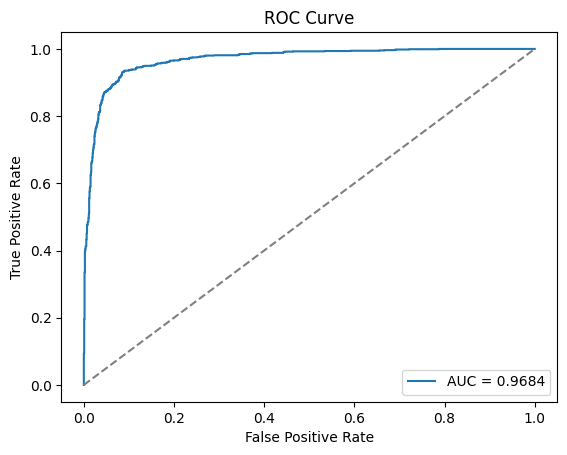

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# For best_model from GridSearchCV
y_probs = best_model.predict_proba(X_test)[:, 1]  # probability for positive class
auc = roc_auc_score(y_test, y_probs)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


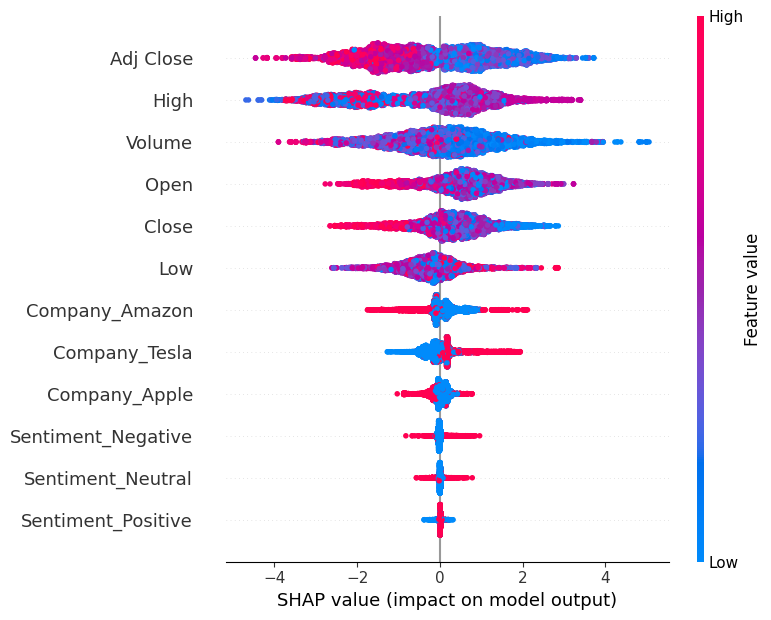

In [ ]:
# Pipeline steps
preprocessor = best_model.named_steps['columntransformer']  # your preprocessing
model = best_model.named_steps[list(best_model.named_steps.keys())[-1]]  # RF/LGBM/GB

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

num_features = numeric_features

cat_features = preprocessor.named_transformers_['cat'] \
    .named_steps['onehotencoder'] \
    .get_feature_names_out(categorical_features)

feature_names = list(num_features) + list(cat_features)


import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_transformed)

# Assuming shap_values is already a 2D array for the target class (as indicated by kernel state)
# If it were a list of 2D arrays (e.g., for multi-class), then shap_values[1] would be correct.
# Given the AssertionError, shap_values is a 2D array and shap_values[1] extracts a 1D row.
shap_values_to_plot = shap_values # Use the full 2D array for summary_plot

shap.summary_plot(
    shap_values_to_plot,
    X_train_transformed,
    feature_names=feature_names
)

Top Features:

Adj Close, High, Volume, Open, Close → most important.

Low Impact Features:

Company and sentiment features have smaller SHAP values → less influence.

Prediction Insights:

High Adj Close values (red) likely push predictions higher.

Low Volume or Open (blue) may push predictions lower.

In [ ]:
import shap
from IPython.display import display

# Initialize JS
shap.initjs()

# Pick first test instance
i = 0
X_instance = X_test_transformed[i]

# Create force plot
force_plot = shap.force_plot(explainer.expected_value, shap_values[i], X_instance)
display(force_plot)


In [ ]:
df.tail()

,Adj Close,Close,High,Low,Open,Volume,Company,Date,Target,Score,Comments,Cleaned_Text,Sentiment,Sentiment_Score,Year,Month,DayOfWeek
12062,205.740005,205.740005,207.639999,205.050003,206.979996,28061600,Amazon,2024-11-27,1,599,345,cut amzn open hopped tesla put recoup 100k lol...,Positive,0.999998,2024,11,2
12063,205.740005,205.740005,207.639999,205.050003,206.979996,28061600,Amazon,2024-11-27,1,25,75,fellow autists today dd older meme check thats...,Neutral,1.000000,2024,11,2
12064,205.740005,205.740005,207.639999,205.050003,206.979996,28061600,Amazon,2024-11-27,1,0,23,im taking hard look spending got thinking amaz...,Positive,0.999907,2024,11,2
12065,205.740005,205.740005,207.639999,205.050003,206.979996,28061600,Amazon,2024-11-27,1,31,307,please use thread discussion dont feel warrant...,Positive,0.999910,2024,11,2
12066,207.889999,207.889999,208.199997,204.589996,205.830002,24892400,Amazon,2024-11-29,1,0,35,previously compared portfolio strategist inves...,Positive,0.999987,2024,11,4


📈 1-DAY AHEAD PREDICTION
----------------------------------------
Last Data Date  : 2024-11-29
Predicted Date  : 2024-11-30
Direction       : DOWN
Confidence      : 0.240


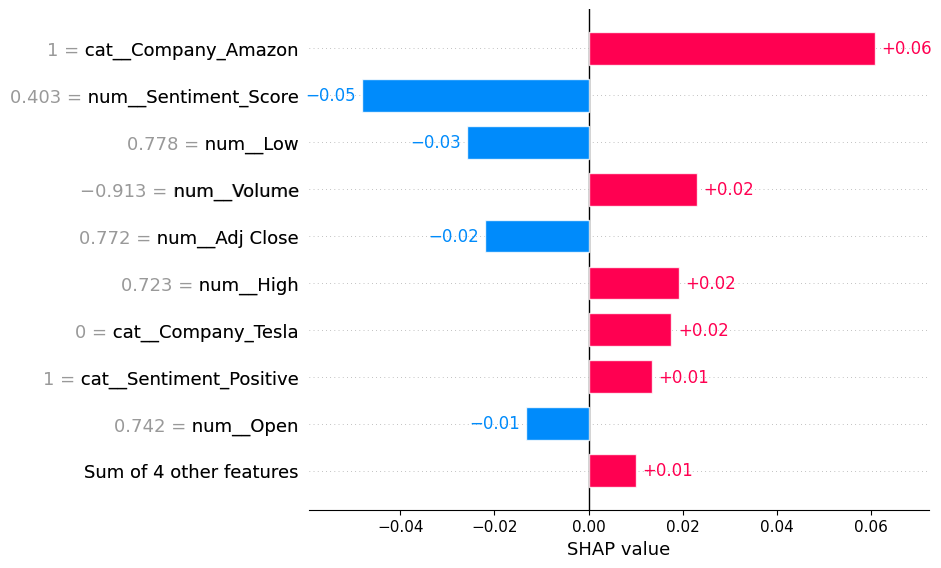

In [ ]:
# ==============================
# 1-DAY AHEAD (T+1) PREDICTION + SHAP EXPLANATION
# ==============================

import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# 1️⃣ Prepare T+1 target (if needed for retraining)
df["Target_1d"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df_1d = df[:-1].copy()  # drop last row where target is NaN

# 2️⃣ Features / target
X = df_1d.drop(columns=["Target_1d"])
y = df_1d["Target_1d"]

# 3️⃣ Preprocessing
numeric_features = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume','Sentiment_Score']
categorical_features = ['Company', 'Sentiment']

numeric_transformer = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='missing'),
    OneHotEncoder(handle_unknown='ignore')
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 4️⃣ Train model for T+1
best_model_1d = make_pipeline(preprocessor, RandomForestClassifier(n_estimators=100, random_state=42))
best_model_1d.fit(X, y)c

# 5️⃣ Prepare T+1 input (last day features)
last_date = df["Date"].iloc[-1]
X_1d = df.drop(columns=["Target_1d"]).iloc[[-1]].copy()
X_1d["Date"] = last_date + pd.Timedelta(days=1)  # for interpretation

# 6️⃣ Predict
pred_1d = best_model_1d.predict(X_1d)[0]
prob_1d = best_model_1d.predict_proba(X_1d)[0,1]
direction_1d = "UP" if pred_1d == 1 else "DOWN"

print("📈 1-DAY AHEAD PREDICTION")
print("-"*40)
print(f"Last Data Date  : {last_date.date()}")
print(f"Predicted Date  : {X_1d['Date'].iloc[0].date()}")
print(f"Direction       : {direction_1d}")
print(f"Confidence      : {prob_1d:.3f}")

# ==============================
# SHAP Explanation
# ==============================

# Split pipeline
preprocessor = best_model_1d.named_steps["columntransformer"]
model = best_model_1d.named_steps[list(best_model_1d.named_steps.keys())[-1]]

# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Transform input and background
X_1d_transformed = preprocessor.transform(X_1d)
X_background_transformed = preprocessor.transform(X.iloc[-100:])

# Convert to DataFrame
X_1d_df = pd.DataFrame(X_1d_transformed, columns=feature_names)
X_background_df = pd.DataFrame(X_background_transformed, columns=feature_names)

# SHAP explainer
explainer = shap.Explainer(model, X_background_df)
shap_values = explainer(X_1d_df)

# Force plot
shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_values.values[0][:,1],
    feature_names=feature_names
)

# Bar plot
shap.plots.bar(shap_values[0][:,1], max_display=10)


📈 5-DAY AHEAD PREDICTION
----------------------------------------
Last Data Date  : 2024-11-29
Predicted Date  : 2024-12-04
Direction       : UP
Confidence      : 0.800


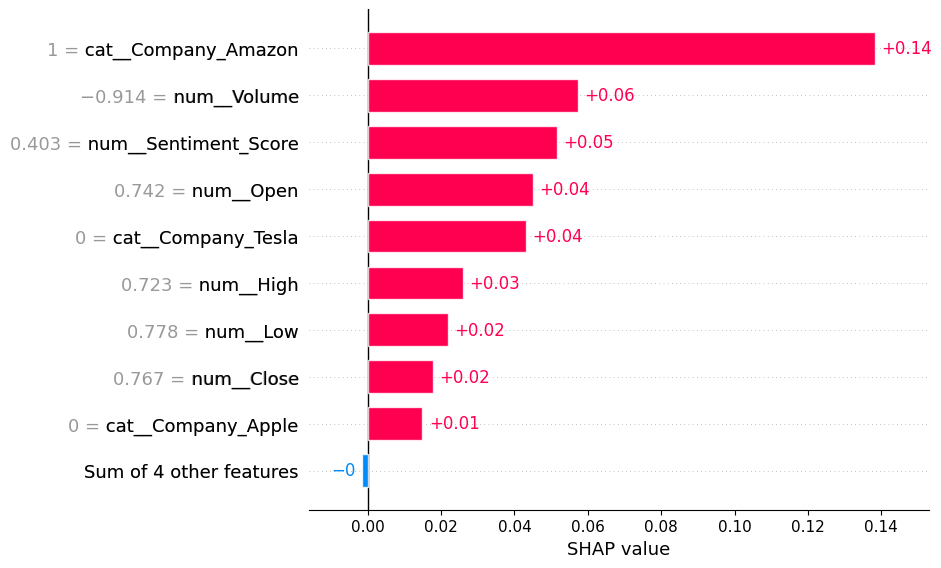

In [ ]:
# ==============================
# 5-DAY AHEAD (T+5) PREDICTION + SHAP EXPLANATION
# ==============================

import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# 1️⃣ Prepare new target 5 days ahead
df["Target_5d"] = (df["Close"].shift(-5) > df["Close"]).astype(int)

# Drop last 5 rows as target is NaN
df_5d = df[:-5].copy()

# 2️⃣ Features / target
X = df_5d.drop(columns=["Target_5d"])
y = df_5d["Target_5d"]

# 3️⃣ Preprocessing (same as before)
numeric_features = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume','Sentiment_Score']
categorical_features = ['Company', 'Sentiment']

numeric_transformer = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='missing'),
    OneHotEncoder(handle_unknown='ignore')
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 4️⃣ Train new model for 5-day prediction
best_model_5d = make_pipeline(preprocessor, RandomForestClassifier(n_estimators=100, random_state=42))
best_model_5d.fit(X, y)

# 5️⃣ Prepare T+5 input (features from last available day)
last_date = df["Date"].iloc[-1]
X_5d = df.drop(columns=["Target_5d"]).iloc[[-1]].copy()

# Update date for interpretation
X_5d["Date"] = last_date + pd.Timedelta(days=5)

# 6️⃣ Predict T+5
pred_5d = best_model_5d.predict(X_5d)[0]
prob_5d = best_model_5d.predict_proba(X_5d)[0, 1]
direction_5d = "UP" if pred_5d == 1 else "DOWN"

print("📈 5-DAY AHEAD PREDICTION")
print("-"*40)
print(f"Last Data Date  : {last_date.date()}")
print(f"Predicted Date  : {X_5d['Date'].iloc[0].date()}")
print(f"Direction       : {direction_5d}")
print(f"Confidence      : {prob_5d:.3f}")

# ==============================
# SHAP Explanation
# ==============================

# Split pipeline
preprocessor = best_model_5d.named_steps["columntransformer"]
model = best_model_5d.named_steps[list(best_model_5d.named_steps.keys())[-1]]

# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Transform input and background
X_5d_transformed = preprocessor.transform(X_5d)
X_background_transformed = preprocessor.transform(X.iloc[-100:])

# Convert to DataFrame
X_5d_df = pd.DataFrame(X_5d_transformed, columns=feature_names)
X_background_df = pd.DataFrame(X_background_transformed, columns=feature_names)

# SHAP explainer
explainer = shap.Explainer(model, X_background_df)
shap_values = explainer(X_5d_df)

# Force plot
shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_values.values[0][:,1],
    feature_names=feature_names
)

# Bar plot
shap.plots.bar(shap_values[0][:,1], max_display=10)
